In [ ]:
#DO NOT IMPORT ANY OTHER LIBRARY
#Run these cells as it is
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import math
from tqdm import tqdm
from copy import deepcopy
import seaborn as sns
try:
    import plotly.graph_objects as go
except:
    !pip install plotly # Or install the plotly library manually

    
    import plotly.graph_objects as go

# required only for jupyter notebooks / while running on colab
%matplotlib inline

# set seed
seed = 2
np.random.seed(seed)

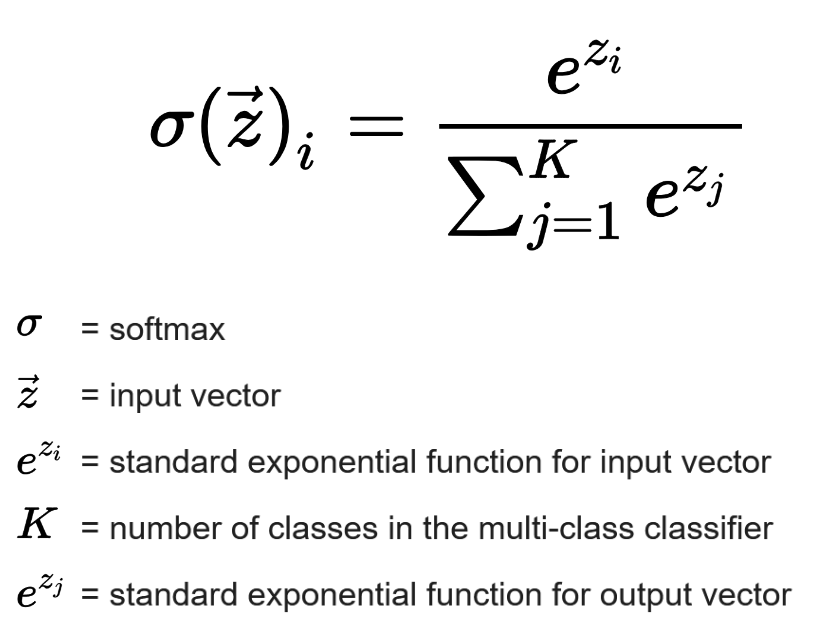

In [2]:
def softmax(z):
    z = np.array(z)
    z_max = np.max(z)       
    exp_values = []
    for i in range(len(z)):
        exp_values.append(np.exp(z[i] - z_max))  
        
    sum_exp = sum(exp_values)
    result = []
    for val in exp_values:
        result.append(val / sum_exp)

    return np.array(result)


def loss_compute(y_pred, yd):
    m = len(yd)
    loss = 0
    loss = -np.sum(yd * np.log(y_pred)) / m
    return loss

In [3]:
def relu(x):
    return np.maximum(0, x)

def drelu(x):
  drelu = lambda x: 1 if x > 0 else 0
  col, row = x.shape
  for i in range(col):
    for j in range(row):
      x[i][j] = drelu(x[i][j])
  return x



def Initialization(I, H1, H2, H3, H4, O):
    W1 = np.random.randn(H1, I) * 0.1
    W2 = np.random.randn(H2, H1) * 0.1
    W3 = np.random.randn(H3, H2) * 0.1
    W4 = np.random.randn(H4, H3) * 0.1
    W5 = np.random.randn(O, H4) * 0.1

    b1 = np.zeros((H1, 1))
    b2 = np.zeros((H2, 1))
    b3 = np.zeros((H3, 1))
    b4 = np.zeros((H4, 1))
    b5 = np.zeros((O, 1))

    return [W1, b1, W2, b2, W3, b3, W4, b4, W5, b5]


def feed_forward(X, params):  
    W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = params

    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(W2, a1) + b2
    a2 = relu(z2)
    z3 = np.dot(W3, a2) + b3
    a3 = relu(z3)
    z4 = np.dot(W4, a3) + b4
    a4 = relu(z4)
    z5 = np.dot(W5, a4) + b5
    a5 = softmax(z5)

    y_out = a5
    l = [z1, a1, z2, a2, z3, a3, z4, a4, z5, a5]
    return y_out , l



def regularization_L2(lmbda, W1, W2, W3, W4, W5, m):
    return (lmbda / (2*m)) * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2) + np.sum(W4**2) + np.sum(W5**2))


def back_prop_linear(da_layer, z_layer, input, act_fxn, m, lmbda, weight):
    dz = da_layer * drelu(z_layer) if act_fxn == 'relu' else da_layer
    dw = (np.dot(dz, input.T) + lmbda * weight) / m
    db = np.sum(dz, axis=1, keepdims=True) / m
    return dz, dw, db

def back_prop_actf(W_next, dz_next):
    return np.dot(W_next.T, dz_next)

def Backpropagation1(X, yd, l, y_pred, parameters, lmbda):
    m = X.shape[1]
    W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = parameters

    dW = [np.zeros_like(W) for W in [W1, W2, W3, W4, W5]]
    db = [np.zeros_like(b) for b in [b1, b2, b3, b4, b5]]

    da = y_pred - yd  

    weights = [W1, W2, W3, W4, W5]
    z = [l[0], l[2], l[4], l[6], l[8]]
    a = [l[1], l[3], l[5], l[7], l[9]]

    for h in reversed(range(5)):
        z_layer = z[h]
        input_layer = X if h == 0 else a[h-1]
        weight = weights[h]
        act_fn = 'relu' if h < 4 else 'none'
        dz, dW[h], db[h] = back_prop_linear(da, z_layer, input_layer, act_fn, m, lmbda, weight)
        if h > 0:
            da = back_prop_actf(weights[h], dz)

    return {
        'dW1': dW[0], 'dW2': dW[1], 'dW3': dW[2], 'dW4': dW[3], 'dW5': dW[4],
        'db1': db[0], 'db2': db[1], 'db3': db[2], 'db4': db[3], 'db5': db[4]
    }


def sgd(W, b, grads, alpha):
    updated_w=W-alpha*grads[0]
    updated_b=b-alpha*grads[1]

    return updated_w,updated_b


def training(X, yd, parameters, eta , num_iters, lmbda):
    m = X.shape[1]
    losses=[]
    W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = parameters
    for _ in range(num_iters):
      y_pred , l = feed_forward(X, parameters)
      loss1=loss_compute(y_pred, yd)
      loss2=regularization_L2(lmbda, W1, W2, W3, W4, W5, m)
      losses.append(loss1+loss2)
      grads_dict = Backpropagation1(X, yd, l, y_pred, parameters, lmbda)
      W1, b1 = sgd(W1, b1, [grads_dict['dW1'], grads_dict['db1']], eta)
      W2, b2 = sgd(W2, b2, [grads_dict['dW2'], grads_dict['db2']], eta)
      W3, b3 = sgd(W3, b3, [grads_dict['dW3'], grads_dict['db3']], eta)
      W4, b4 = sgd(W4, b4, [grads_dict['dW4'], grads_dict['db4']], eta)
      W5, b5 = sgd(W5, b5, [grads_dict['dW5'], grads_dict['db5']], eta)
      parameters = [W1, b1, W2, b2, W3, b3, W4, b4, W5, b5]
    return losses, parameters

def one_hot_encode(y, num_classes):
    one_hot = np.zeros((num_classes, y.shape[1]))
    one_hot[y, np.arange(y.shape[1])] = 1
    return one_hot




In [28]:
df_train = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

Y_train = df_train.iloc[:, 0].values.reshape(1, -1)
X_train = df_train.iloc[:, 1:].values.T / 255.0

Y_test = df_test.iloc[:, 0].values.reshape(1, -1)
X_test = df_test.iloc[:, 1:].values.T / 255.0

Y_train_oh = one_hot_encode(Y_train, 10)
Y_test_oh = one_hot_encode(Y_test, 10)


input_size = 784
hidden1 = 256
hidden2 = 128
hidden3 = 64
hidden4 = 32
output_size = 10

params = Initialization(input_size, hidden1, hidden2, hidden3, hidden4, output_size)

eta = 0.1
num_iters = 1
lambda_reg = 0.01
batch_size = 100
epoch = 20
m = X_train.shape[1]



all_losses = []

for ep in range(epoch):
    permutation = np.random.permutation(m)
    X_train_shuffled = X_train[:, permutation]
    Y_train_oh_shuffled = Y_train_oh[:, permutation]

    for i in range(0, m, batch_size):
        X_batch = X_train_shuffled[:, i:i+batch_size]
        Y_batch = Y_train_oh_shuffled[:, i:i+batch_size]
        losses, params = training(X_batch, Y_batch, params, eta, num_iters, lambda_reg)
        all_losses.extend(losses)


y_test_pred, _ = feed_forward(X_test, params)
y_pred_labels = np.argmax(y_test_pred, axis=0)
y_actual_labels = Y_test.flatten()

accuracy = np.mean(y_pred_labels == y_actual_labels) * 100


y_train_pred, _ = feed_forward(X_train, params)
y_train_pred_labels = np.argmax(y_train_pred, axis=0)
y_train_actual_labels = Y_train.flatten()

train_accuracy = np.mean(y_train_pred_labels == y_train_actual_labels) * 100

print(f"train accuracy: {train_accuracy:.2f}%")
print(f"test accuracy: {accuracy:.2f}%")


train accuracy: 100.00%
test accuracy: 98.05%


Final loss: 0.1164


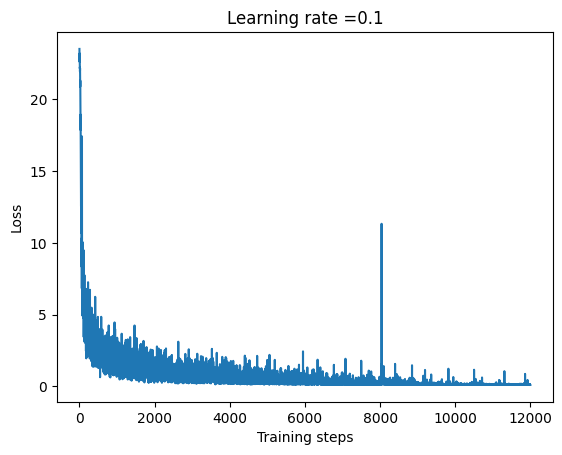

In [29]:
print(f"Final loss: {all_losses[-1]:.4f}")
plt.plot(all_losses)
plt.ylabel('Loss')
plt.xlabel('Training steps')
plt.title("Learning rate ="  + str(eta))
plt.show()


<div dir="rtl">
در ابتدا فرم کلی تابع سافت مکس رو با سرچ در اینترنت بدست آوردم سپس لاس رو بر اساس cross-entropy که یه جورایی شبیه انتروپی در درخت تصمیم بود بدست آوردم.

بعد تابع one-hot پیاده سازی شدش تا هر عدد رو به یه ماتریس نسبت بده که این باعث میشد که مقدار لاس محاسبه شده صحیح باشد و به مقدار عدد ربطی نداشته باشد.

در ابتدا که نميدوستم تابع فعالسازي لايه آخر سافت مکس و لاس از کراس انتروپي بدست ميآيد با انجام هر کار (اضافه کردن بچ و ایتریشن نامبر و تعداد اپوک ها) دقت حدود 9 تا 11 درصد قرار میگرفت که نشان دهنده آندرفیت بود 

در ابتدا با تعداد ایتریشن پایین مقدار مناسب برای لرنینگ ریت را برابر 0.1 بدست آوردم.

سپس ابتدا با ایتریشن های بالا امتحان کردم و دقت رو بدست آوردم که مثلا در ایتریشن 100 مقدار دقت تست 85.72 بود که حدود 0.5 درصد بالاتر از دقت ترین بود.

با بچ سایز 100 و ایتریشن 10 ما با سرعت بالاتر به دقت 94.47 در تست و 94.83 در ترین رسیدیم. چون سرعت محاسبه با وجود بچ بالاتر بود بنابراین از بچ در تمامی مراحل استفاده میکنیم.

حالا می آییم و تعداد اپوک ها را قرار میدهیم. چون اپوک در حلقه اصلی است مقدار ایتریشن رو یک قرار میدهیم چون اپوک خودش تعداد بار هایی که کل داده ها به مدل داده میشود رو هندل میکند. در اپوک 5 دقت داده های تست برابر96.71 و در داده های ترین برابر97.93 شدش.


دلیل بالاتر رفتن دقت با استفاده از اپوک:
در هر اپوک، کل داده‌ها رو با batchهای کوچکتر می‌دی به مدل.
در هر ایتریشن، فقط یک batch از اون داده‌ها می‌ره توی مدل.


حالا با همین تعداد اپوک از شافل کردن یا همان بر زدن داده ها استفاده میکنیم تا ببینیم این کار تاثیری دارد یا نه.
با شافل کردن داده ها در هر اپوک مقدار ترین یک درصد و مقدار تست حدود 0.5 درصد افزایش یافت.

با اپوک بیست:

train accuracy: 100.00%

test accuracy: 98.05%

Final loss: 0.1164


با بیشتر اپوک و رسیدن اپوک به مثلا 25 دقت تست کمتر میشود و این نشان دهنده شروع اورفیت است
پس به مدل بهینه رسیدیم